# Part 3

In [9]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, window, avg, to_timestamp, rand, sqrt
from pyspark.sql import SparkSession

HOST_IP = "10.248.16.109"

existing = SparkSession.getActiveSession()
if existing:
    existing.stop()

spark = (
    SparkSession.builder
    .appName('Journey-Part3')
    .master(f'spark://{HOST_IP}:7077')
    .config('spark.driver.host', HOST_IP)
    .config('spark.driver.bindAddress', HOST_IP)
    .config('spark.eventLog.enabled', 'true')
    .config('spark.eventLog.dir', 'file:///tmp/spark-events')
    .getOrCreate()
)
spark


In [10]:
df = pd.read_csv('/home/bfh/rtdp/bfh-rtdp/roller/RawData.csv', sep=';', decimal=',')
df.columns = ['time_s', 'gx', 'gy', 'gz', 'absolute']
df['timestamp'] = df['time_s'] + time.time()

df.head()

,time_s,gx,gy,gz,absolute,timestamp
0,0.021205,0.004554,-0.018110,0.007252,0.020033,1.780150e+09
1,0.031272,0.035954,-0.021800,0.012549,0.043880,1.780150e+09
2,0.041339,0.058538,-0.047381,0.004798,0.075464,1.780150e+09
3,0.051406,0.066985,-0.087119,0.013295,0.110696,1.780150e+09
4,0.061473,0.071572,-0.115078,0.017367,0.136627,1.780150e+09


In [11]:
sdf = spark.createDataFrame(df[['timestamp', 'gx', 'gy', 'gz', 'absolute']]) \
    .withColumn('zeit', to_timestamp(col('timestamp').cast('long')))

result = (
    sdf.groupBy(window('zeit', '1 second'))
    .agg(avg('absolute').alias('avg_absolute'))
    .orderBy('window')
    .select(col('window.start').alias('start'), 'avg_absolute')
    .toPandas()
)

result.head()

,start,avg_absolute
0,2026-05-30 16:13:57,0.283977
1,2026-05-30 16:13:58,0.544884
2,2026-05-30 16:13:59,0.735977
3,2026-05-30 16:14:00,1.289315
4,2026-05-30 16:14:01,1.130003


In [12]:
axes_result = (
    sdf.groupBy(window('zeit', '1 second'))
    .agg(avg('gx').alias('avg_gx'), avg('gy').alias('avg_gy'), avg('gz').alias('avg_gz'))
    .orderBy('window')
    .select(col('window.start').alias('start'), 'avg_gx', 'avg_gy', 'avg_gz')
    .toPandas()
)

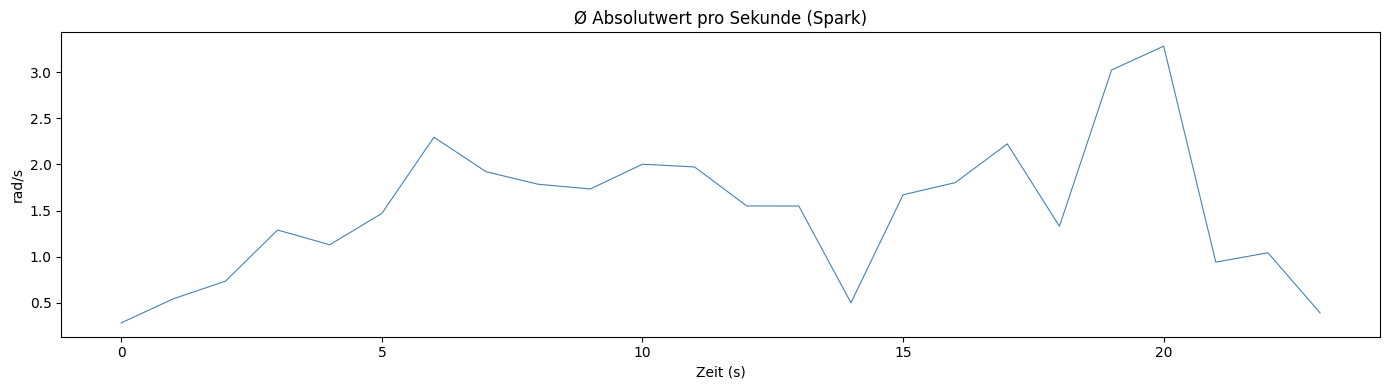

In [13]:
t = (result['start'] - result['start'].min()).dt.total_seconds()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, result['avg_absolute'], linewidth=0.8, color='steelblue')
ax.set_title('Ø Absolutwert pro Sekunde (Spark)')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('rad/s')
plt.tight_layout()
plt.show()


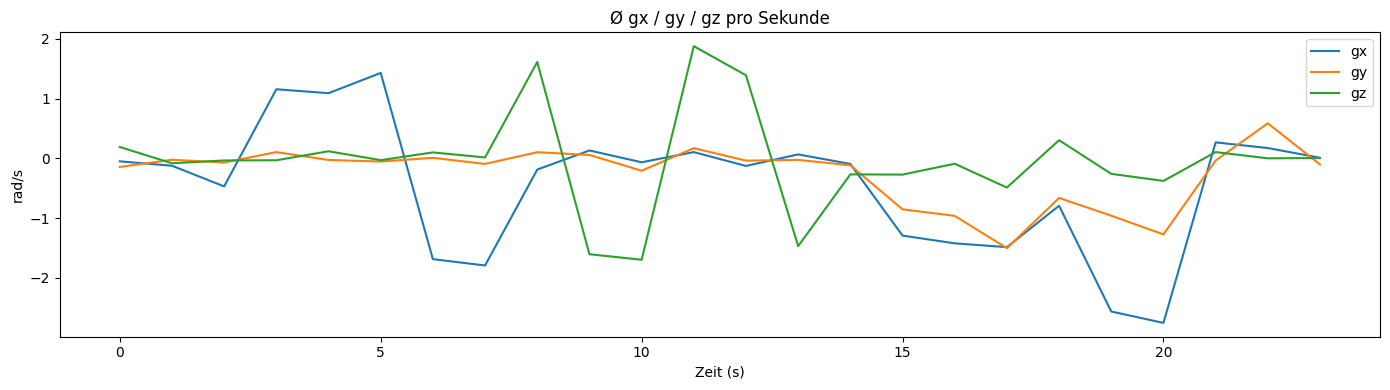

In [14]:


t = (axes_result['start'] - axes_result['start'].min()).dt.total_seconds()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, axes_result['avg_gx'], label='gx')
ax.plot(t, axes_result['avg_gy'], label='gy')
ax.plot(t, axes_result['avg_gz'], label='gz')
ax.set_title('Ø gx / gy / gz pro Sekunde')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('rad/s')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
spark.stop()
